<a href="https://colab.research.google.com/github/yunayana/Sztuczna_Inteligencja_STAC_2026/blob/main/Lab3_klasyfikacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
#Biblioteka numpy ułatwia pracę z macierzami i wielowymiarowymi tabelami.
import numpy as np
#Biblioteka Tensorflow posłuży nam do zbudowania modelu
import tensorflow as tf
#Biblioteka opencv-python - biblioteka typu open source do przetwarzania obrazu i uczenia maszynowego.
import cv2
#Wizualizacja danych.
import matplotlib.pyplot as plt
#TensorFlow zawiera dostawcę danych dla MNIST, z którego będziemy korzystać
import tensorflow_datasets as tfds

In [49]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [50]:
# należy znormalizować nasze dane, aby wynik był bardziej stabilny numerycznie
# dane wejściowe muszą być w zakresie liczbowym od 0 do 1
# zdefiniujmy funkcję o nazwie: scale, która pobierze obraz MNIST i jego etykietę

def scale(image, label):
# potrzebujemy wartości zmiennoprzecinkowej float
   image = tf.cast(image, tf.float32)
# ponieważ możliwe wartości dla wejść to od 0 do 255 (256 różnych odcieni szarości)
# jeśli podzielimy każdy element przez 255, otrzymamy pożądany wynik:
# wszystkie elementy będą znajdować się w przedziale od 0 do 1
   image /= 255.
   return image, label

# metoda .map () pozwala nam zastosować niestandardową transformację do danego zbioru danych
# już zdecydowaliśmy, że otrzymamy dane walidacyjne z mnist_train, więc
scaled_train_and_validation_data = mnist_train.map(scale)

# na koniec normalizujemy i grupujemy dane testowe
# aby miały taką samą wielkość jak dane trenjące i walidacyjne
# nie ma potrzeby ich mieszania, ponieważ nie będziemy trenować na danych testowych
# będzie to pojedyncza partia równa wielkości danych testowych
test_data = mnist_test.map(scale)

In [51]:
# ten parametr BUFFER_SIZE jest tutaj w przypadkach, gdy mamy do czynienia z ogromnymi zbiorami danych
# wtedy nie możemy przetasować całego zestawu danych za jednym razem,
# ponieważ nie możemy zmieścić go w pamięci
# więc zamiast tego TF przechowuje w pamięci tylko BUFFER_SIZE próbki na raz i tasuje je
# if BUFFER_SIZE = 1 => żadne tasowanie nie nastąpi
# if BUFFER_SIZE> = liczba próbek => tasowanie jest jednolite
# BUFFER_SIZE pomiędzy - optymalizacja obliczeniowa w celu przybliżenia jednolitego tasowania
BUFFER_SIZE = 1000

# jest łatwo dostępna metoda shuffle i musimy tylko określić rozmiar bufora
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# po przeskalowaniu i przetasowaniu danych możemy przystąpić do faktycznego wyodrębniania
# danych trenujących i walidacyjnych
# nasze dane walidacyjne byłyby równe 10% zbioru uczącego, który już obliczyliśmy
# używamy metody .take(), aby pobrać tyle próbek
# na koniec tworzymy partię o wielkości równej całkowitej liczbie próbek walidacyjnych
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)

# podobnie train_data to wszystko inne, więc pomijamy tyle próbek
# ile jest w zbiorze danych walidacyjnych
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [52]:
# zmienna określająca wielkość partii podawanej podczas trenowania
BATCH_SIZE = 100

# tworzymy partie danych treningowych
# jest to bardzo pomocne podczas treningu, ponieważ możęmy iterować po różnych partiach
train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)

test_data = test_data.batch(num_test_samples)

# pobieramy i iterujemy partię walidacyjną (jest to jedyna partia)
# ponieważ as_supervized = True, mamy strukturę składającą się z dwóch krotek
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [53]:
input_size = 784 # 28 x 28 pikseli
output_size = 10 # 10 różnych cyfr

# Użyjemy tego samego rozmiaru ukrytej warstwy dla obu ukrytych warstw. Nie jest to konieczne.
hidden_layer_size = 50

#MODEL
model = tf.keras. Sequential([

# Pierwsza warstwa to warstwa wejściowa.
# Każda próbka ma wymiary 28x28x1 pikseli, dlatego jest to tensor rozmiaru 3.
# Ponieważ to nie jest jeszcze CNN, nie wiemy, jak wprowadzić takie dane wejściowe
# do naszej sieci, więc musimy spłaszczyć obrazy.
# istnieje wygodna warstwa „Flatten”, która po prostu pobiera nasz tensor 28x28x1
# i porządkuje go w (None,) lub (28x28x1,)=(784,)
# to pozwala nam faktycznie stworzyć sieć neuronową typu feed forward
   tf.keras.layers.Flatten(input_shape=(28, 28, 1)), # input layer, warstwa wejściowa

# tf.keras.layers.Dense jest w zasadzie implementacją modelu liniowego:
# y = xw + b czyli output = activation(dot(input, weight) + bias)
# wymaga kilku argumentów, ale najważniejsze dla nas to hidden_layer_size i funkcja aktywacji
tf.keras.layers.Dense(hidden_layer_size, activation='relu'), # warstwa ukryta
tf.keras.layers.Dense(hidden_layer_size, activation='relu'), # warstwa ukryta

# ostatnia warstwa nie jest inna, po prostu upewniamy się,
# że aktywujemy ją za pomocą softmax, która daje nam rozkład prawdopodobieństwa
# i ma rozmiar output_size
tf.keras.layers.Dense(output_size, activation='softmax' ) # output layer

])

# określamy na końcu funkcję optymalizacji, którego chcielibyśmy użyć,
# funkcja straty, # oraz metryki, które chcemy uzyskać w każdej epocy uczenia
model. compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy' ])

In [54]:
# ustawiamy ilość epok
NUM_EPOCHS = 30

# ustaw mechanizm wczesnego zatrzymywania, który ochroni nasz model przed przetrenowaniem
# ustawmy patience=2, aby być nieco tolerancyjnym na losowe wzrosty strat walidacji
early_stopping = tf.keras.callbacks. EarlyStopping(patience=2)

# dopasowujemy model, określając dane treningowe, łączną liczbę epok
# oraz dane walidacyjne, które właśnie stworzyliśmy, w formacie: (INPUTS, TARGETS),

model.fit(train_data, # dane wejściowe trenujące
          epochs=NUM_EPOCHS, # maksymalna ilość epok gdyby wczesne zatrzymanie nie zadziałało
          callbacks=[early_stopping], # mechanizm "early stopping" - zapobieganie przetrenowaniu
          validation_data=(validation_inputs, validation_targets), # dane walidacyjne
          verbose = 1 # sposób pokazania treningu modelu
           )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8811 - loss: 0.4083 - val_accuracy: 0.9405 - val_loss: 0.2092
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9493 - loss: 0.1744 - val_accuracy: 0.9535 - val_loss: 0.1612
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9611 - loss: 0.1337 - val_accuracy: 0.9502 - val_loss: 0.1585
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9682 - loss: 0.1087 - val_accuracy: 0.9580 - val_loss: 0.1353
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9731 - loss: 0.0920 - val_accuracy: 0.9608 - val_loss: 0.1311
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9756 - loss: 0.0816 - val_accuracy: 0.9620 - val_loss: 0.1206
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9796 - loss: 0.0697 - val_accuracy: 0.9637 - val_loss: 0.1218
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9808 - loss: 0.0631 - val_accura

In [55]:
test_loss, test_accuracy = model.evaluate(test_data)
# możemy zastosować estetyczne formatowanie
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9714 - loss: 0.1038
Test loss: 0.10. Test accuracy: 97.14%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Rozpoznana cyfra: 5
Prawdopodobieństwa: [[2.6305293e-20 1.4268815e-04 1.8578314e-10 6.3583241e-07 0.0000000e+00
  9.9985671e-01 1.5858764e-23 1.1382510e-20 6.0109376e-30 2.0487834e-20]]


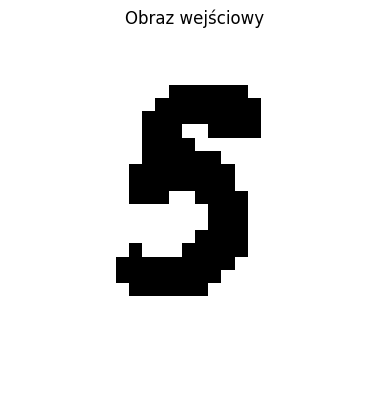

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('moja_cyfra.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))

_, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

img = 255 - img

img = img.astype('float32') / 255.0
img = img.reshape(1, 28, 28, 1)

plt.imshow(img[0, :, :, 0], cmap='gray')
plt.title("Obraz wejściowy")
plt.axis('off')

preds = model.predict(img)
predicted_label = np.argmax(preds, axis=1)[0]

print("Rozpoznana cyfra:", predicted_label)
print("Prawdopodobieństwa:", preds)